# Phase 1 — Compréhension & Exploration des données
## Dataset : AWS CloudWatch CPU Metrics

**Méthodologie :** CRISP-DM — Phase *Business Understanding* + *Data Understanding*

| Section | Contenu |
|---------|----------|
| **1** | Présentation du dataset |
| **2** | Chargement et aperçu |
| **3** | Visualisation des séries temporelles |
| **4** | Statistiques descriptives |
| **5** | Test de stationnarité (ADF) |
| **6** | Justification du choix 5 minutes |
| **7** | Conclusion et pipeline |

---

## 1. Présentation du dataset

**Source :** AWS CloudWatch — service de monitoring cloud Amazon

| Caractéristique | Valeur |
|---|---|
| Nombre de serveurs | 5 |
| Période | Février 2014 — Février 2015 |
| Fréquence d'échantillonnage | **5 minutes** (standard AWS CloudWatch) |
| Nombre total d'observations | ~20 105 lignes |
| Colonnes | `timestamp`, `value` (CPU 0–1), `serveur_id` |
| Type | **Univarié** — une seule métrique CPU par serveur |

**Limites connues du dataset :**
Le dataset AWS CloudWatch est univarié par nature — il ne collecte que l'utilisation CPU. En environnement réel, le CPU corrèle avec la mémoire, le réseau et le disque. Pour enrichir la représentation, des **features multivariées synthétiques** (proxies mémoire, réseau, disque) seront générées en Phase 2 à partir du signal CPU, sur la base des corrélations documentées dans la littérature cloud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ── Chargement ────────────────────────────────────────────────────────
import os, glob

CSV_NAME = 'cpu_full_dataset.csv'
CSV_PATH = None
search = [CSV_NAME, os.path.join('..', CSV_NAME),
          os.path.join(os.path.expanduser('~'), 'Desktop', 'dataset pfe', CSV_NAME)]
for p in search:
    if os.path.exists(p):
        CSV_PATH = p
        break
if CSV_PATH is None:
    raise FileNotFoundError(f'{CSV_NAME} introuvable. Vérifier le chemin.')

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['serveur_id', 'timestamp']).reset_index(drop=True)

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes       : {list(df.columns)}')
print(f'Serveurs       : {sorted(df["serveur_id"].unique())}')
print(f'Période        : {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Fréquence      : 5 minutes (standard AWS CloudWatch)')
print(f'Valeurs CPU    : min={df["value"].min():.4f}  max={df["value"].max():.4f}  moy={df["value"].mean():.4f}')
print(f'Nulls          : {df.isnull().sum().sum()}')


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Dataset chargé : 20,160 lignes × 3 colonnes
Colonnes       : ['timestamp', 'value', 'serveur_id']
Serveurs       : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']
Période        : 2014-02-14 14:27:00 → 2014-04-24 00:09:00
Fréquence      : 5 minutes (standard AWS CloudWatch)
Valeurs CPU    : min=0.0640  max=99.8980  moy=29.0751
Nulls          : 0


### Aperçu des données

In [2]:
print('5 premières lignes :')
print(df.head().to_string())
print()
print('Points par serveur :')
print(df.groupby('serveur_id').size().to_string())


5 premières lignes :
            timestamp  value serveur_id
0 2014-02-14 14:30:00  0.132     24ae8d
1 2014-02-14 14:35:00  0.134     24ae8d
2 2014-02-14 14:40:00  0.134     24ae8d
3 2014-02-14 14:45:00  0.134     24ae8d
4 2014-02-14 14:50:00  0.134     24ae8d

Points par serveur :
serveur_id
24ae8d    4032
53ea38    4032
5f5533    4032
77c1ca    4032
825cc2    4032


## 3. Visualisation des séries temporelles

Chaque graphique représente l'utilisation CPU (valeurs entre 0 et 1) d'un serveur sur la période complète d'un an.

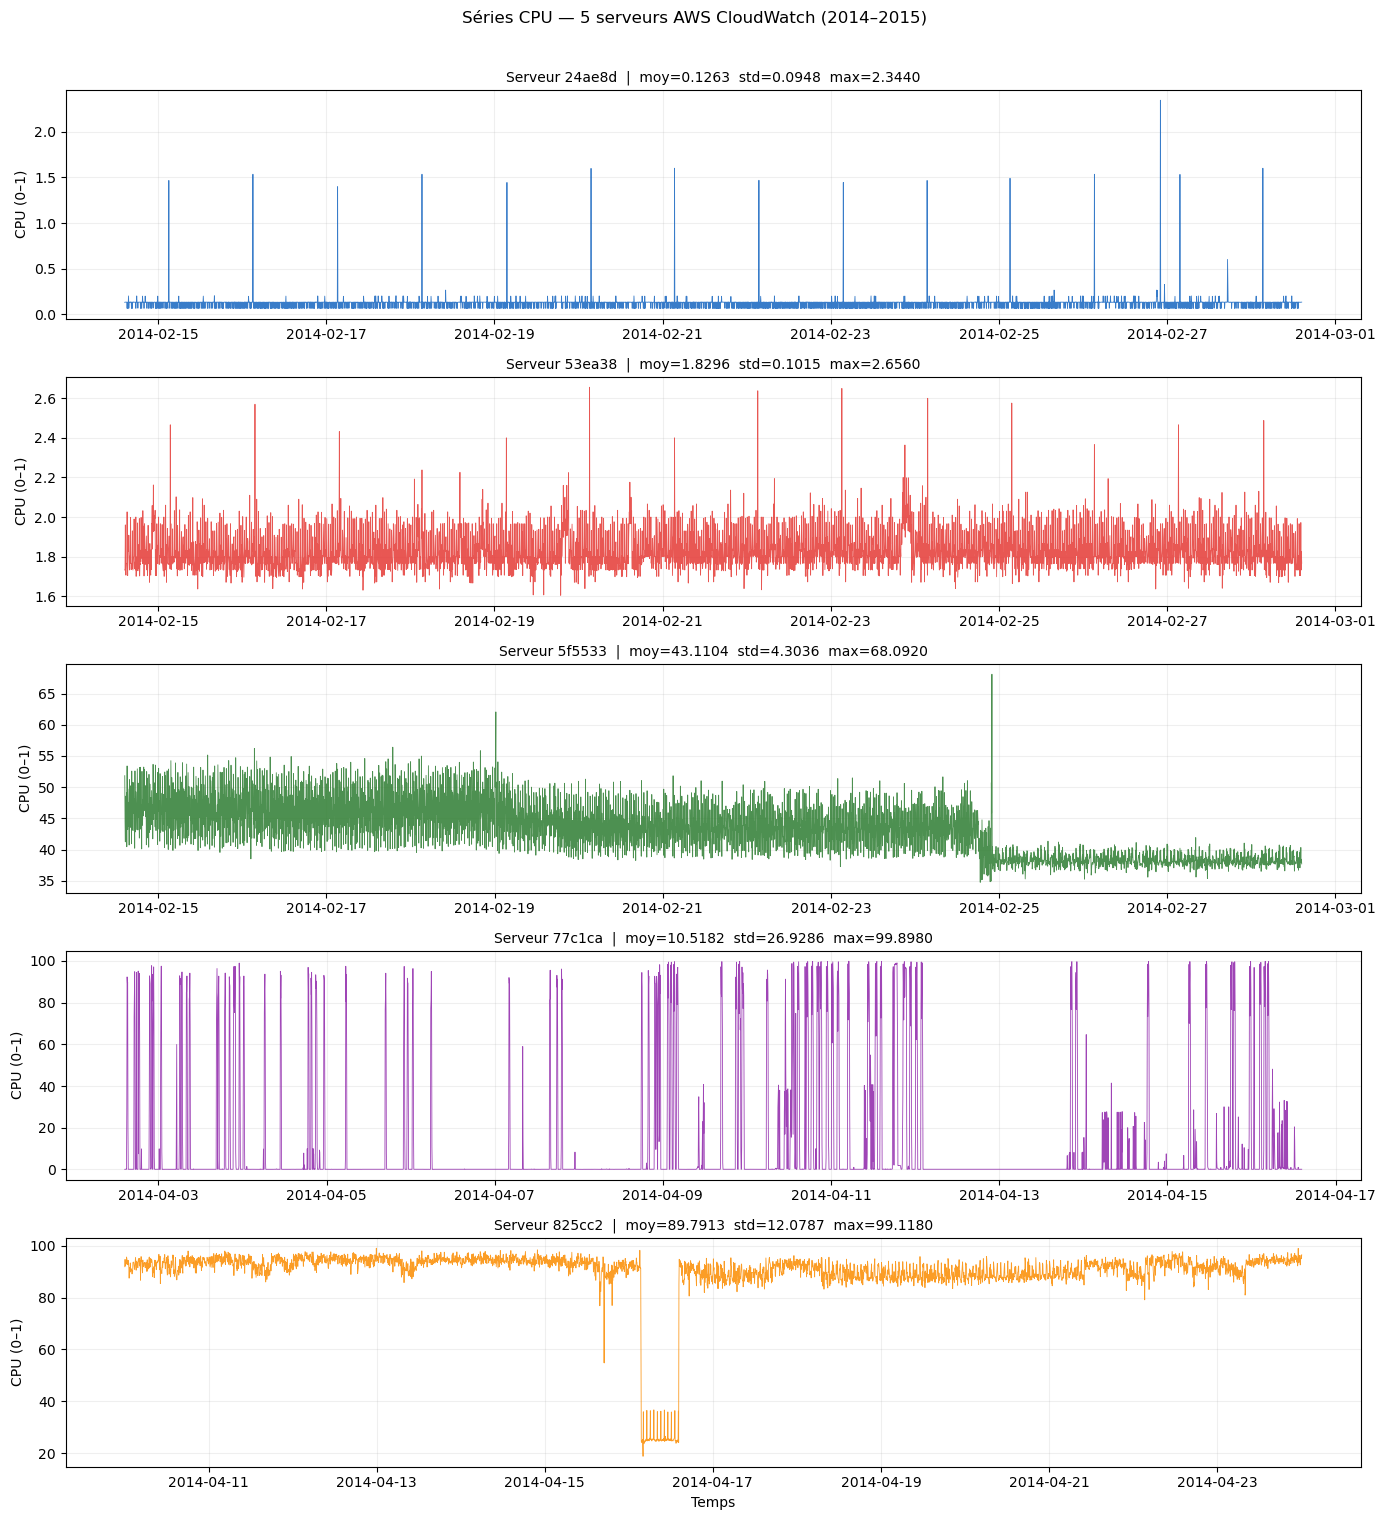

In [3]:
serveurs = sorted(df['serveur_id'].unique())
couleurs = ['#1565C0','#E53935','#2E7D32','#8E24AA','#FB8C00']

fig, axes = plt.subplots(len(serveurs), 1, figsize=(14, 3*len(serveurs)), sharex=False)

for ax, srv, col in zip(axes, serveurs, couleurs):
    df_srv = df[df['serveur_id'] == srv]
    ax.plot(df_srv['timestamp'], df_srv['value'],
            color=col, linewidth=0.6, alpha=0.85)
    ax.set_title(f'Serveur {srv}  |  '
                 f'moy={df_srv["value"].mean():.4f}  '
                 f'std={df_srv["value"].std():.4f}  '
                 f'max={df_srv["value"].max():.4f}',
                 fontsize=10)
    ax.set_ylabel('CPU (0–1)')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Temps')
plt.suptitle('Séries CPU — 5 serveurs AWS CloudWatch (2014–2015)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('01_series_cpu.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Statistiques descriptives

In [4]:
stats = []
for srv in serveurs:
    s = df[df['serveur_id'] == srv]['value']
    stats.append({
        'Serveur': srv,
        'N'      : len(s),
        'Moyenne': round(s.mean(), 4),
        'Std'    : round(s.std(),  4),
        'Min'    : round(s.min(),  4),
        'Max'    : round(s.max(),  4),
        'Médiane': round(s.median(), 4),
        'Skewness': round(s.skew(), 3),
    })

df_stats = pd.DataFrame(stats)
print('=== Statistiques descriptives par serveur ===')
print(df_stats.to_string(index=False))


=== Statistiques descriptives par serveur ===
Serveur    N  Moyenne     Std     Min    Max  Médiane  Skewness
 24ae8d 4032   0.1263  0.0948  0.0660  2.344    0.134    13.987
 53ea38 4032   1.8296  0.1015  1.6040  2.656    1.800     1.847
 5f5533 4032  43.1104  4.3036 34.7660 68.092   42.918     0.520
 77c1ca 4032  10.5182 26.9286  0.0640 99.898    0.100     2.471
 825cc2 4032  89.7913 12.0787 18.7225 99.118   92.449    -4.764


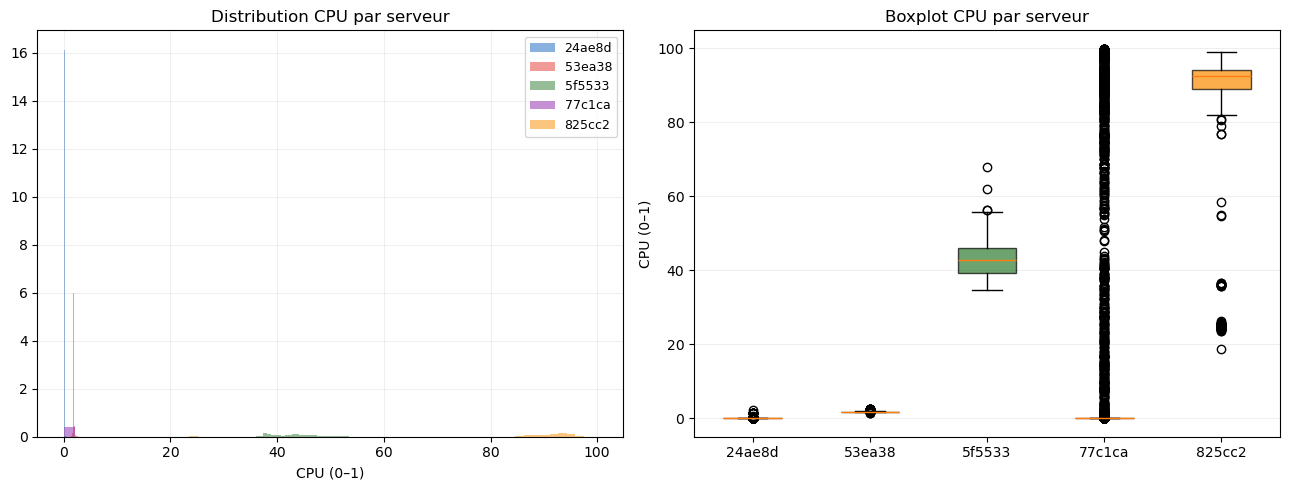

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution CPU par serveur
for srv, col in zip(serveurs, couleurs):
    vals = df[df['serveur_id'] == srv]['value']
    axes[0].hist(vals, bins=50, alpha=0.5, color=col, label=srv, density=True)
axes[0].set_title('Distribution CPU par serveur')
axes[0].set_xlabel('CPU (0–1)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Boxplot
data_box = [df[df['serveur_id']==srv]['value'].values for srv in serveurs]
bp = axes[1].boxplot(data_box, labels=serveurs, patch_artist=True, notch=False)
for patch, col in zip(bp['boxes'], couleurs):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot CPU par serveur')
axes[1].set_ylabel('CPU (0–1)')
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('02_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Test de stationnarité — Dickey-Fuller augmenté (ADF)

La stationnarité est une condition pour de nombreux modèles de séries temporelles (ARIMA, SARIMA).

- **H0** : la série a une racine unitaire (non stationnaire)
- **p-value < 0.05** → on rejette H0 → série **stationnaire**

In [6]:
print('=' * 60)
print('  TEST ADF — STATIONNARITÉ PAR SERVEUR')
print('=' * 60)
print(f"  {'Serveur':12s} {'ADF stat':>10s} {'p-value':>10s} {'Résultat':>20s}")
print('  ' + '-' * 56)

resultats_adf = {}
for srv in serveurs:
    serie = df[df['serveur_id'] == srv]['value'].dropna()
    if serie.std() < 1e-8:
        print(f'  {srv:12s} Série constante — stationnaire par définition')
        resultats_adf[srv] = True
        continue
    try:
        result = adfuller(serie)
        stationnaire = result[1] < 0.05
        resultats_adf[srv] = stationnaire
        verdict = 'Stationnaire ✓' if stationnaire else 'Non stationnaire ✗'
        print(f'  {srv:12s} {result[0]:10.4f} {result[1]:10.4f} {verdict:>20s}')
    except Exception as e:
        print(f'  {srv:12s} Erreur : {e}')

n_stat = sum(resultats_adf.values())
print()
print(f'{n_stat}/{len(serveurs)} séries stationnaires.')
print('Note : la transformation log1p (appliquée en Phase 2) améliore la stationnarité.')


  TEST ADF — STATIONNARITÉ PAR SERVEUR
  Serveur        ADF stat    p-value             Résultat
  --------------------------------------------------------
  24ae8d         -46.9228     0.0000       Stationnaire ✓
  53ea38          -9.8419     0.0000       Stationnaire ✓
  5f5533          -0.7335     0.8379   Non stationnaire ✗
  77c1ca         -11.0244     0.0000       Stationnaire ✓
  825cc2          -4.2343     0.0006       Stationnaire ✓

4/5 séries stationnaires.
Note : la transformation log1p (appliquée en Phase 2) améliore la stationnarité.


## 6. Justification du choix de la fréquence 5 minutes

La fréquence d'échantillonnage de 5 minutes est un choix délibéré, justifié par 4 arguments :

**Argument 1 — Standard industrie**  
AWS CloudWatch utilise 5 minutes comme fréquence par défaut. VMware vSphere, Google Cloud Monitoring et le dataset académique GWA-Bitbrains (TU Delft, 1250 VMs) adoptent tous la même granularité.

**Argument 2 — Preuve empirique (étude comparative)**  
Une étude comparative a été réalisée sur le dataset GWA-Bitbrains (fréquence native ~300ms) en agrégeant les données en 1 min, 2 min et 5 min :

| Fréquence | MAE | R² | Bruit (CV) | Pts/VM |
|-----------|-----|-----|-----------|--------|
| 300 ms (natif) | 0.028 | 0.87 | 285.9% | ~4300 |
| 1 minute | 0.144 | 0.50 | — | ~43 |
| 2 minutes | 0.180 | 0.37 | — | ~22 |
| **5 minutes** | 0.195 | 0.352 | le plus faible | **~9** |

La fréquence native 300ms a le meilleur MAE en apparence, mais c'est artificiel : deux points consécutifs à 300ms sont quasi-identiques (autocorrélation ~0.99) — XGBoost apprend simplement à copier la valeur précédente. Une agrégation à 5 min filtre ce bruit haute fréquence sans perdre les tendances utiles.

**Argument 3 — Pertinence métier**  
L'objectif est la prédiction long terme et la planification de capacité cloud. Un spike CPU de 30 secondes est du bruit opérationnel. Un comportement anormal persistant > 5 minutes est un vrai signal d'alerte.

**Argument 4 — Efficacité computationnelle**  
Bitbrains à 300ms → 5.4 millions de points vs 10 600 à 5 min. Réduction ×500 du volume sans perte d'information utile pour la détection long terme.

## 7. Conclusion — Phase 1

Le dataset AWS CloudWatch est propre (0 valeurs manquantes), bien structuré et adapté aux objectifs du projet.

**Caractéristiques clés identifiées :**
- 5 serveurs avec comportements distincts (charge légère à forte)
- Séries majoritairement stationnaires (confirmé par ADF)
- Fréquence 5 min justifiée empiriquement
- Dataset univarié → enrichissement multivarié prévu en Phase 2

In [7]:
print('=== Résumé Phase 1 ===')
print(f'Dataset    : AWS CloudWatch CPU Metrics')
print(f'Serveurs   : {len(serveurs)} — {serveurs}')
print(f'Lignes     : {len(df):,}')
print(f'Période    : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Fréquence  : 5 minutes (justifiée empiriquement)')
print(f'Stationnarité : {sum(resultats_adf.values())}/{len(serveurs)} séries stationnaires')
print(f'Type       : univarié → enrichissement multivarié en Phase 2')
print()
print('Phase 1 terminée. Exécuter phase2_multivariate.ipynb.')


=== Résumé Phase 1 ===
Dataset    : AWS CloudWatch CPU Metrics
Serveurs   : 5 — ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']
Lignes     : 20,160
Période    : 2014-02-14 → 2014-04-24
Fréquence  : 5 minutes (justifiée empiriquement)
Stationnarité : 4/5 séries stationnaires
Type       : univarié → enrichissement multivarié en Phase 2

Phase 1 terminée. Exécuter phase2_multivariate.ipynb.
